# ROY relative lattice energy tight correction

In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.io import read

In [3]:
ROOT = Path("/mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis")

POLYMORPHS = [
    "Y",
    "YT04",
    "R",
    "OP",
    "YN",
    "ON",
    "ORP",
]

REFERENCE_FORM = "Y"

# ROY formula: C12H9N3O2S
# 12 + 9 + 3 + 2 + 1 = 27 atoms per molecule
ATOMS_PER_ROY_MOLECULE = 27

EV_TO_KJ_MOL = 96.4853321233

In [4]:
EXPERIMENT = {
    "Y": 0.0,
    "YT04": 0.9,
    "R": 1.4,
    "OP": 1.9,
    "YN": 3.0,
    "ON": 2.6,
    "ORP": 4.1,
}
B86 = {
    "Y": 0.000,
    "YT04": -0.440,
    "R": -6.388,
    "OP": -3.802,
    "YN": 0.930,
    "ON": -4.280,
    "ORP": -4.684,
}
SCS = {
    "Y": 0.000,
    "YT04": 0.642,
    "R": 0.825,
    "OP": 1.607,
    "YN": 2.313,
    "ON": 3.016,
    "ORP": 4.290,
}
REFERENCE_COLUMN = "Experiment"





In [5]:
DIRECTORIES = {
    "relax": {
        "B97M lightdenser": (
            ROOT
            / "B97M"
            / "lightdenser"
            / "ROY_relax"
        ),
        "B97M tight": (
            ROOT
            / "B97M"
            / "tight"
            / "ROY_relax"
        ),
        "wB97M lightdenser": (
            ROOT
            / "wB97M"
            / "lightdenser"
            / "ROY_relax"
        ),
    },

    "unrelax": {
        "B97M lightdenser": (
            ROOT
            / "B97M"
            / "lightdenser"
            / "ROY_unrelax"
        ),
        "B97M tight": (
            ROOT
            / "B97M"
            / "tight"
            / "ROY_unrelax"
        ),
        "wB97M lightdenser": (
            ROOT
            / "wB97M"
            / "lightdenser"
            / "ROY_unrelax"
        ),
    },
}

In [6]:

 def find_aims_output(base_dir, polymorph):
    """
    Find the output file for one ROY polymorph.

    Expected filename patterns include:
        Y_aims.out
        Y_relax_aims.out
        Y_unrelax_aims.out
        YT04_aims.out
        YN_relax_aims.out

    Matching requires the filename to begin with:
        <polymorph>_

    Therefore, Y will not match YT04 or YN.
    """

    base_dir = Path(base_dir)

    if not base_dir.is_dir():
        raise FileNotFoundError(
            f"Directory does not exist: {base_dir}"
        )

    prefix = f"{polymorph.lower()}_"

    matches = sorted(
        path
        for path in base_dir.rglob("*.out")
        if path.name.lower().startswith(prefix)
    )

    if not matches:
        raise FileNotFoundError(
            f"No output file beginning with "
            f"'{polymorph}_' was found under:\n"
            f"{base_dir}"
        )

    completed_matches = []

    for path in matches:
        try:
            text = path.read_text(
                errors="ignore"
            )

            if "Have a nice day" in text[-50000:]:
                completed_matches.append(path)

        except OSError:
            continue

    if len(completed_matches) == 1:
        return completed_matches[0]

    if len(completed_matches) > 1:
        message = "\n".join(
            f"  {path}"
            for path in completed_matches
        )

        raise RuntimeError(
            f"Multiple completed output files were found "
            f"for {polymorph}:\n{message}"
        )

    if len(matches) == 1:
        warnings.warn(
            f"{matches[0]} does not contain "
            f"'Have a nice day'. The calculation may "
            f"be incomplete."
        )

        return matches[0]

    message = "\n".join(
        f"  {path}"
        for path in matches
    )

    raise RuntimeError(
        f"Multiple possible output files were found "
        f"for {polymorph}, but none appear complete:\n"
        f"{message}"
    )

In [7]:
for calculation_type, method_paths in DIRECTORIES.items():

    print(f"\n{calculation_type.upper()}")

    for method_name, directory in method_paths.items():

        print(f"\n{method_name}")

        for polymorph in POLYMORPHS:

            try:
                output_file = find_aims_output(
                    directory,
                    polymorph,
                )

                print(
                    f"{polymorph:5s}: "
                    f"{output_file}"
                )

            except Exception as error:

                print(
                    f"{polymorph:5s}: "
                    f"ERROR - {error}"
                )


RELAX

B97M lightdenser
Y    : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/Y_relax_aims.out
YT04 : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/YT04_relax_aims.out
R    : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/R_relax_aims.out
OP   : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/OP_relax_aims.out
YN   : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/YN_relax_aims.out
ON   : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/ON_relax_aims.out
ORP  : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax/ORP_relax_aims.out

B97M tight
Y    : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/tight/ROY_relax/Y_relax_aims.out
YT04 : /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/tight/ROY_relax/YT04_relax_aims.out
R    : /mnt/ceph/users/cwood

In [8]:
# Read all FHI-aims energies

all_energies = {}
all_file_information = {}
reading_errors = []

for calculation_type, method_paths in DIRECTORIES.items():

    print("\n" + "=" * 80)
    print(calculation_type.upper())
    print("=" * 80)

    all_energies[calculation_type] = {}
    all_file_information[calculation_type] = {}

    for method_name, directory in method_paths.items():

        print(f"\n{method_name}")
        print(f"Directory: {directory}")

        method_energies = {}
        method_file_information = {}

        for polymorph in POLYMORPHS:

            try:
                output_file = find_aims_output(
                    directory,
                    polymorph,
                )

                atoms = read(
                    output_file,
                    format="aims-output",
                    index=-1,
                )

                total_energy_ev = float(
                    atoms.get_potential_energy()
                )

                number_of_atoms = len(atoms)

                if (
                    number_of_atoms
                    % ATOMS_PER_ROY_MOLECULE
                    != 0
                ):
                    raise ValueError(
                        f"{output_file.name} contains "
                        f"{number_of_atoms} atoms, which "
                        f"is not divisible by "
                        f"{ATOMS_PER_ROY_MOLECULE}."
                    )

                number_of_molecules = (
                    number_of_atoms
                    // ATOMS_PER_ROY_MOLECULE
                )

                energy_per_molecule_ev = (
                    total_energy_ev
                    / number_of_molecules
                )

                method_energies[polymorph] = (
                    energy_per_molecule_ev
                )

                method_file_information[
                    polymorph
                ] = {
                    "output_file": output_file,
                    "total_energy_ev": total_energy_ev,
                    "energy_per_molecule_ev": (
                        energy_per_molecule_ev
                    ),
                    "number_of_atoms": number_of_atoms,
                    "number_of_molecules": (
                        number_of_molecules
                    ),
                }

                print(
                    f"  {polymorph:>4}: "
                    f"{energy_per_molecule_ev: .10f} "
                    f"eV/molecule | "
                    f"{number_of_molecules} molecule(s) | "
                    f"{output_file.name}"
                )

            except Exception as error:

                reading_errors.append(
                    {
                        "calculation_type": calculation_type,
                        "method": method_name,
                        "polymorph": polymorph,
                        "error": str(error),
                    }
                )

                print(
                    f"  {polymorph:>4}: "
                    f"ERROR — {error}"
                )

        all_energies[
            calculation_type
        ][method_name] = method_energies

        all_file_information[
            calculation_type
        ][method_name] = (
            method_file_information
        )

if reading_errors:

    error_table = pd.DataFrame(
        reading_errors
    )

    print(
        "\nOne or more files could not be read:"
    )

    display(error_table)

else:

    print(
        "\nAll requested FHI-aims energies "
        "were read successfully."
    )


RELAX

B97M lightdenser
Directory: /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/lightdenser/ROY_relax
     Y: -32070.2435451570 eV/molecule | 4 molecule(s) | Y_relax_aims.out
  YT04: -32070.2495648420 eV/molecule | 4 molecule(s) | YT04_relax_aims.out
     R: -32070.2803613292 eV/molecule | 2 molecule(s) | R_relax_aims.out
    OP: -32070.2439349105 eV/molecule | 4 molecule(s) | OP_relax_aims.out
    YN: -32070.2320874235 eV/molecule | 2 molecule(s) | YN_relax_aims.out
    ON: -32070.2512952395 eV/molecule | 4 molecule(s) | ON_relax_aims.out
   ORP: -32070.2242118299 eV/molecule | 8 molecule(s) | ORP_relax_aims.out

B97M tight
Directory: /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/B97M/tight/ROY_relax
     Y: -32072.8242953983 eV/molecule | 4 molecule(s) | Y_relax_aims.out
  YT04: -32072.8443767580 eV/molecule | 4 molecule(s) | YT04_relax_aims.out
     R: -32072.8689609073 eV/molecule | 2 molecule(s) | R_relax_aims.out
    OP: -32072.8366403007 eV/molecule | 4 mole

In [9]:
absolute_energy_tables = {}

for calculation_type in DIRECTORIES:

    table = pd.DataFrame(
        {
            method_name: pd.Series(
                method_energies
            )
            for method_name, method_energies
            in all_energies[
                calculation_type
            ].items()
        }
    )

    table = table.reindex(
        POLYMORPHS
    )

    table.index.name = "Polymorph"

    absolute_energy_tables[
        calculation_type
    ] = table

    print(
        f"\n{calculation_type.upper()} "
        f"absolute energies (eV/molecule)"
    )

    display(
        table.round(10)
    )


RELAX absolute energies (eV/molecule)


,B97M lightdenser,B97M tight,wB97M lightdenser
Polymorph,,,
Y,-32070.243545,-32072.824295,-32067.330355
YT04,-32070.249565,-32072.844377,-32067.340583
R,-32070.280361,-32072.868961,-32067.329226
OP,-32070.243935,-32072.836640,-32067.302515
YN,-32070.232087,-32072.807657,-32067.315597
ON,-32070.251295,-32072.831011,-32067.327488
ORP,-32070.224212,-32072.820809,-32067.276375



UNRELAX absolute energies (eV/molecule)


,B97M lightdenser,B97M tight,wB97M lightdenser
Polymorph,,,
Y,-32070.165952,-32072.738942,-32067.218970
YT04,-32070.172492,-32072.754960,-32067.222712
R,-32070.199858,-32072.783604,-32067.189536
OP,-32070.173225,-32072.717971,-32067.175059
YN,-32070.155131,-32072.720567,-32067.195614
ON,-32070.167976,-32072.742454,-32067.182872
ORP,-32070.130624,-32072.717971,-32067.130273


In [10]:
def calculate_relative_energies(
    energy_dictionary,
    reference_polymorph=REFERENCE_FORM,
):
    """
    Convert absolute energies in eV/molecule into relative
    energies in kJ/mol.
    """

    missing_polymorphs = [
        polymorph
        for polymorph in POLYMORPHS
        if polymorph not in energy_dictionary
    ]

    if missing_polymorphs:
        raise KeyError(
            "Missing absolute energies for: "
            + ", ".join(missing_polymorphs)
        )

    if reference_polymorph not in energy_dictionary:
        raise KeyError(
            f"Reference polymorph "
            f"{reference_polymorph} is missing."
        )

    reference_energy_ev = (
        energy_dictionary[
            reference_polymorph
        ]
    )

    relative_energies = {
        polymorph: (
            energy_dictionary[polymorph]
            - reference_energy_ev
        )
        * EV_TO_KJ_MOL
        for polymorph in POLYMORPHS
    }

    return pd.Series(
        relative_energies,
        name="Relative energy",
        dtype=float,
    )

In [11]:
def build_corrected_table(calculation_type):
    """
    Build the relative-energy table for either 'relax'
    or 'unrelax'.
    """

    if calculation_type not in all_energies:
        raise KeyError(
            f"No energies were loaded for "
            f"{calculation_type!r}."
        )

    required_methods = [
        "B97M lightdenser",
        "B97M tight",
        "wB97M lightdenser",
    ]

    missing_methods = [
        method
        for method in required_methods
        if method not in all_energies[
            calculation_type
        ]
    ]

    if missing_methods:
        raise KeyError(
            f"Missing methods for "
            f"{calculation_type}: "
            + ", ".join(missing_methods)
        )

    b97m_light_relative = (
        calculate_relative_energies(
            all_energies[
                calculation_type
            ][
                "B97M lightdenser"
            ]
        )
    )

    b97m_tight_relative = (
        calculate_relative_energies(
            all_energies[
                calculation_type
            ][
                "B97M tight"
            ]
        )
    )

    wb97m_light_relative = (
        calculate_relative_energies(
            all_energies[
                calculation_type
            ][
                "wB97M lightdenser"
            ]
        )
    )

    # B97M tight-basis correction
    basis_correction = (
        b97m_tight_relative
        - b97m_light_relative
    )

    # Apply the B97M basis correction to wB97M
    wb97m_corrected_relative = (
        wb97m_light_relative
        + basis_correction
    )

    results = pd.DataFrame(
        index=POLYMORPHS
    )

    results.index.name = "Polymorph"

    results["Experiment"] = pd.Series(
    EXPERIMENT,
    dtype=float,
)

    results["B86bPBE-XDM"] = pd.Series(
    B86,
    dtype=float,
)

    results["SCS-MP2D corrected"] = pd.Series(
    SCS,
    dtype=float,
)

    results["B97M lightdenser"] = (
        b97m_light_relative
    )

    results["B97M tight"] = (
        b97m_tight_relative
    )

    results["wB97M lightdenser"] = (
        wb97m_light_relative
    )

    results["wB97M corrected"] = (
        wb97m_corrected_relative
    )

    results = results.reindex(
        POLYMORPHS
    )

    return results

In [12]:
relaxed_results = build_corrected_table(
    "relax"
)

unrelaxed_results = build_corrected_table(
    "unrelax"
)

print(
    "Relaxed relative energies "
    "(kJ/mol, relative to Y)"
)

display(
    relaxed_results.round(3)
)

print(
    "\nUnrelaxed relative energies "
    "(kJ/mol, relative to Y)"
)

display(
    unrelaxed_results.round(3)
)

Relaxed relative energies (kJ/mol, relative to Y)


,Experiment,B86bPBE-XDM,SCS-MP2D corrected,B97M lightdenser,B97M tight,wB97M lightdenser,wB97M corrected
Polymorph,,,,,,,
Y,0.0,0.000,0.000,0.000,0.000,0.000,0.000
YT04,0.9,-0.440,0.642,-0.581,-1.938,-0.987,-2.344
R,1.4,-6.388,0.825,-3.552,-4.310,0.109,-0.648
OP,1.9,-3.802,1.607,-0.038,-1.191,2.686,1.533
YN,3.0,0.930,2.313,1.106,1.605,1.424,1.924
ON,2.6,-4.280,3.016,-0.748,-0.648,0.277,0.376
ORP,4.1,-4.684,4.290,1.865,0.336,5.208,3.679



Unrelaxed relative energies (kJ/mol, relative to Y)


,Experiment,B86bPBE-XDM,SCS-MP2D corrected,B97M lightdenser,B97M tight,wB97M lightdenser,wB97M corrected
Polymorph,,,,,,,
Y,0.0,0.000,0.000,0.000,0.000,0.000,0.000
YT04,0.9,-0.440,0.642,-0.631,-1.545,-0.361,-1.276
R,1.4,-6.388,0.825,-3.271,-4.309,2.840,1.802
OP,1.9,-3.802,1.607,-0.702,2.023,4.237,6.962
YN,3.0,0.930,2.313,1.044,1.773,2.254,2.982
ON,2.6,-4.280,3.016,-0.195,-0.339,3.483,3.339
ORP,4.1,-4.684,4.290,3.409,2.023,8.558,7.173


In [13]:
def calculate_metrics(
    results_table,
    reference_column="Experiment",
    reference_polymorph="Y",
):
    """
    Calculate errors relative to experiment, excluding the
    reference polymorph because its relative energy is fixed
    to zero by definition.
    """

    methods_to_compare = [
        "B86bPBE-XDM",
        "SCS-MP2D corrected",
        "B97M lightdenser",
        "B97M tight",
        "wB97M lightdenser",
        "wB97M corrected",
    ]

    comparison_table = results_table.drop(
        index=reference_polymorph
    )

    reference_values = comparison_table[
        reference_column
    ].to_numpy(dtype=float)

    metric_rows = []

    for method_name in methods_to_compare:

        predicted_values = comparison_table[
            method_name
        ].to_numpy(dtype=float)

        errors = predicted_values - reference_values

        rmse = np.sqrt(
            np.mean(errors**2)
        )

        metric_rows.append(
            {
                "Method": method_name,
                "RMSE (kJ/mol)": rmse,

            }
        )

    return pd.DataFrame(
        metric_rows
    ).set_index("Method")

In [14]:
relaxed_metrics = calculate_metrics(
    relaxed_results
)

unrelaxed_metrics = calculate_metrics(
    unrelaxed_results
)

print(
    "Relaxed structures: metrics relative to "
    "Experimental values"
)

display(
    relaxed_metrics.round(4)
)

print(
    "\nUnrelaxed structures: metrics relative to "
    "Experimental values"
)

display(
    unrelaxed_metrics.round(4)
)

Relaxed structures: metrics relative to Experimental values


,RMSE (kJ/mol)
Method,
B86bPBE-XDM,6.1065
SCS-MP2D corrected,0.4405
B97M lightdenser,2.8943
B97M tight,3.5792
wB97M lightdenser,1.5788
wB97M corrected,1.8766



Unrelaxed structures: metrics relative to Experimental values


,RMSE (kJ/mol)
Method,
B86bPBE-XDM,6.1065
SCS-MP2D corrected,0.4405
B97M lightdenser,2.6787
B97M tight,2.9734
wB97M lightdenser,2.2485
wB97M corrected,2.5983


Saved figure to: /mnt/ceph/users/cwoodson/DFTProject/DFT/mol_analysis/ROY_correlation_plot.png


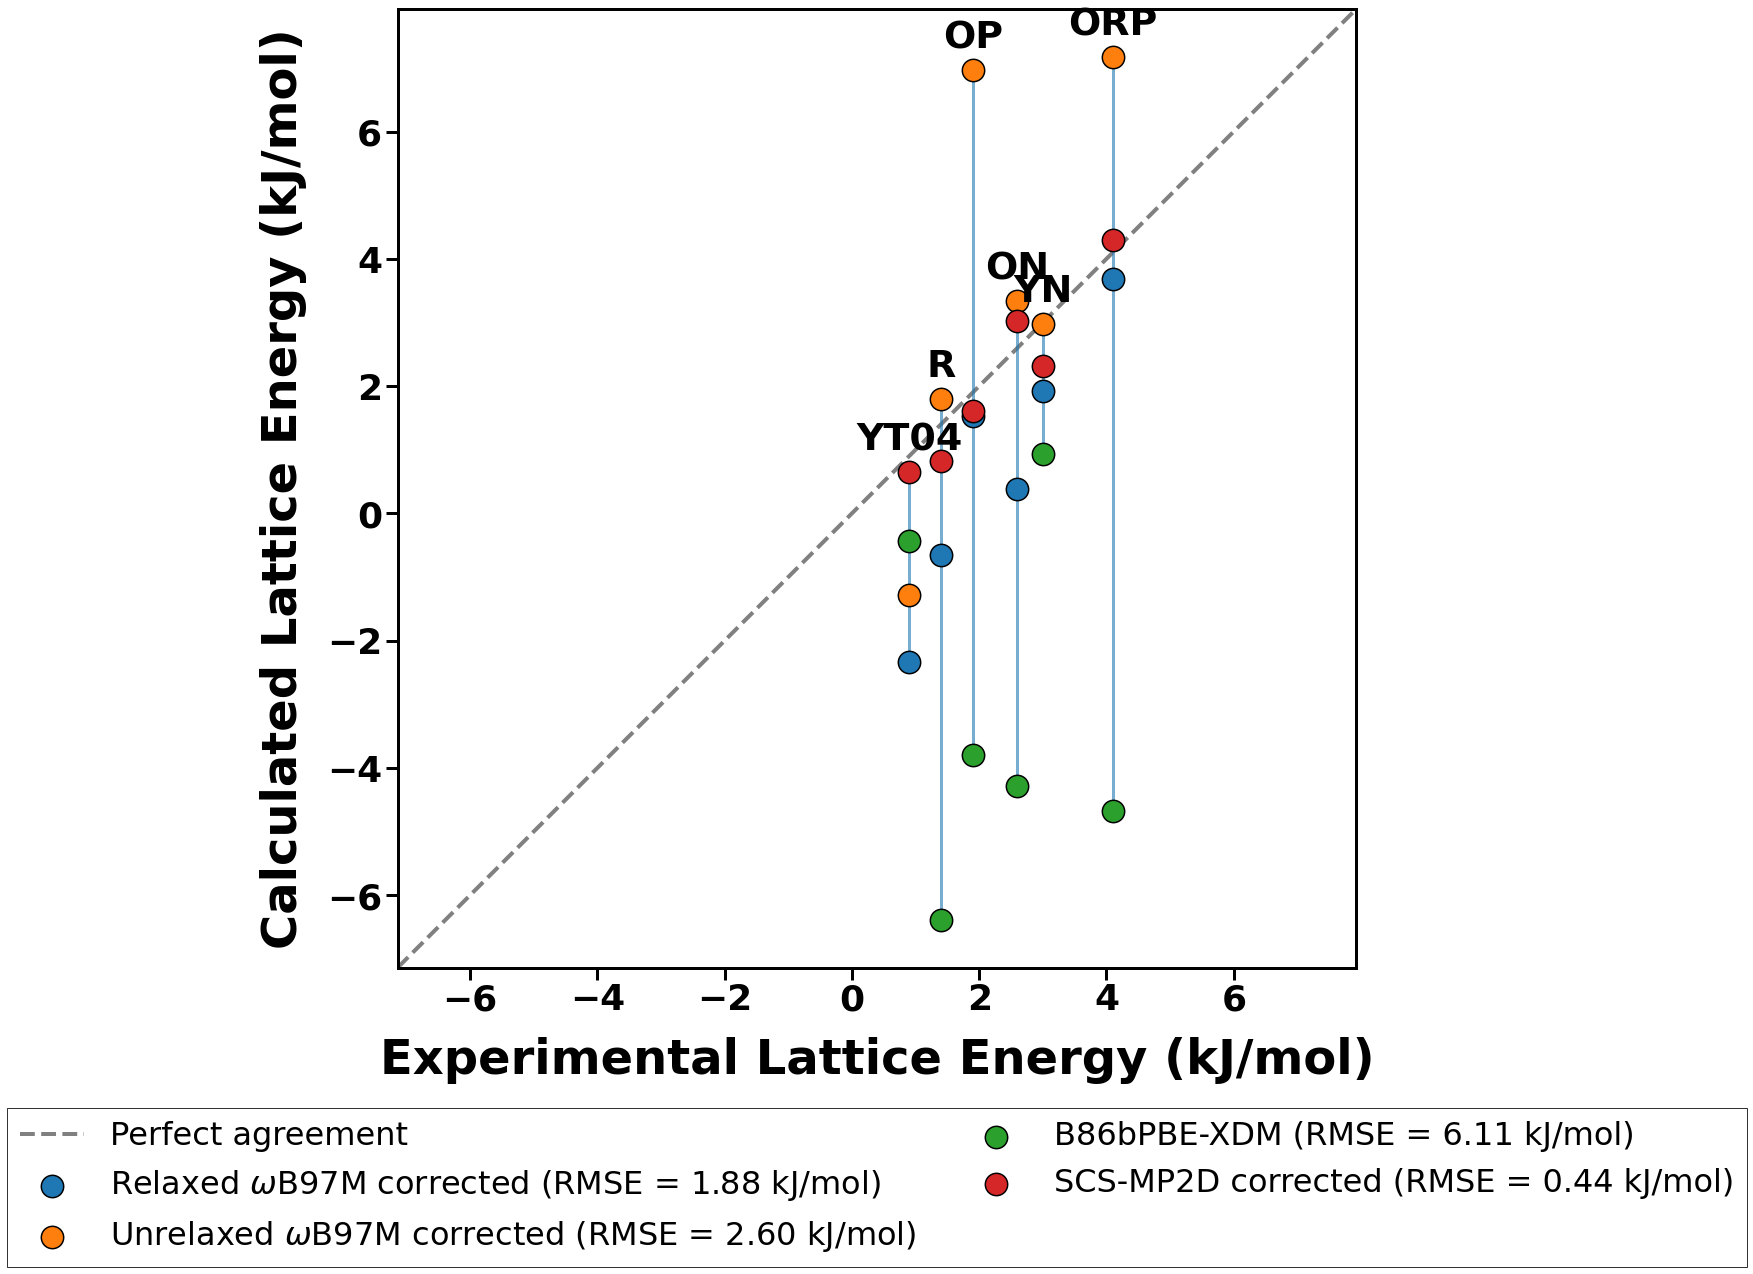

In [15]:
def plot_correlation(relaxed_results, unrelaxed_results):

    polymorphs = [
        polymorph
        for polymorph in POLYMORPHS
        if polymorph != "Y"
    ]

    experiment = relaxed_results.loc[
        polymorphs,
        "Experiment",
    ].to_numpy(dtype=float)

    methods = {
        r"Relaxed $\omega$B97M corrected": (
            relaxed_results.loc[
                polymorphs,
                "wB97M corrected",
            ].to_numpy(dtype=float)
        ),
        r"Unrelaxed $\omega$B97M corrected": (
            unrelaxed_results.loc[
                polymorphs,
                "wB97M corrected",
            ].to_numpy(dtype=float)
        ),
        "B86bPBE-XDM": (
            relaxed_results.loc[
                polymorphs,
                "B86bPBE-XDM",
            ].to_numpy(dtype=float)
        ),
        "SCS-MP2D corrected": (
            relaxed_results.loc[
                polymorphs,
                "SCS-MP2D corrected",
            ].to_numpy(dtype=float)
        ),
    }

    fig, ax = plt.subplots(figsize=(22, 20))

    all_values = list(experiment)

    for calculated_values in methods.values():
        all_values.extend(calculated_values)

    plot_min = min(all_values) - 0.75
    plot_max = max(all_values) + 0.75

    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=4.0,
        color="gray",
        label="Perfect agreement",
        zorder=1,
    )

    for method_name, calculated_values in methods.items():

        rmse = np.sqrt(
            np.mean(
                (calculated_values - experiment) ** 2
            )
        )

        legend_label = (
            f"{method_name} "
            f"(RMSE = {rmse:.2f} kJ/mol)"
        )

        ax.scatter(
            experiment,
            calculated_values,
            s=500,
            edgecolor="black",
            linewidth=1.5,
            label=legend_label,
            zorder=3,
        )

    method_arrays = list(methods.values())

    for index, polymorph in enumerate(polymorphs):

        x_value = experiment[index]

        polymorph_values = [
            calculated_values[index]
            for calculated_values in method_arrays
        ]

        y_min = min(polymorph_values)
        y_max = max(polymorph_values)

        ax.vlines(
            x=x_value,
            ymin=y_min,
            ymax=y_max,
            linewidth=3.0,
            alpha=0.6,
            zorder=2,
        )

        ax.annotate(
            polymorph,
            xy=(x_value, y_max),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=38,
            fontweight="bold",
            zorder=4,
        )

    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        "Experimental Lattice Energy (kJ/mol)",
        fontsize=48,
        fontweight="bold",
        labelpad=20,
    )

    ax.set_ylabel(
        "Calculated Lattice Energy (kJ/mol)",
        fontsize=48,
        fontweight="bold",
        labelpad=20,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=36,
        length=12,
        width=3,
    )

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(3)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13),
        fontsize=32,
        frameon=True,
        edgecolor="black",
        fancybox=False,
        ncol=2,
        columnspacing=1.5,
        handletextpad=0.8,
    )

    fig.tight_layout(
        rect=[0, 0.10, 1, 1]
    )

    output_file = (
        ROOT
        / "ROY_correlation_plot.png"
    )

    fig.savefig(
        output_file,
        dpi=600,
        bbox_inches="tight",
    )

    print(f"Saved figure to: {output_file}")

    plt.show()


plot_correlation(
    relaxed_results,
    unrelaxed_results,
)